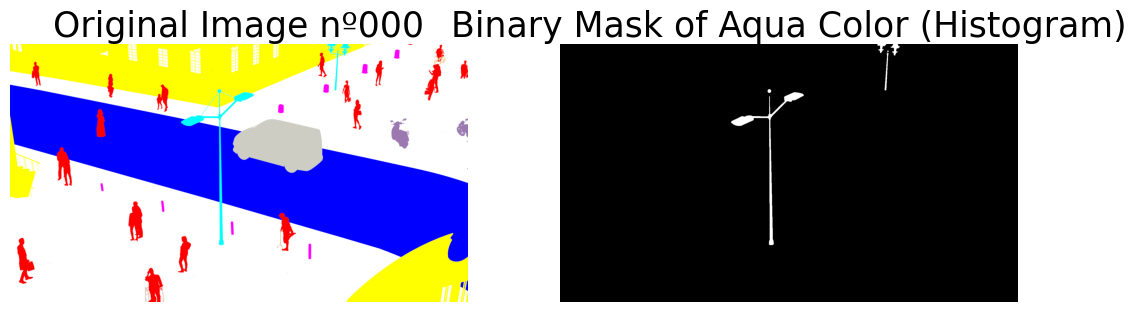

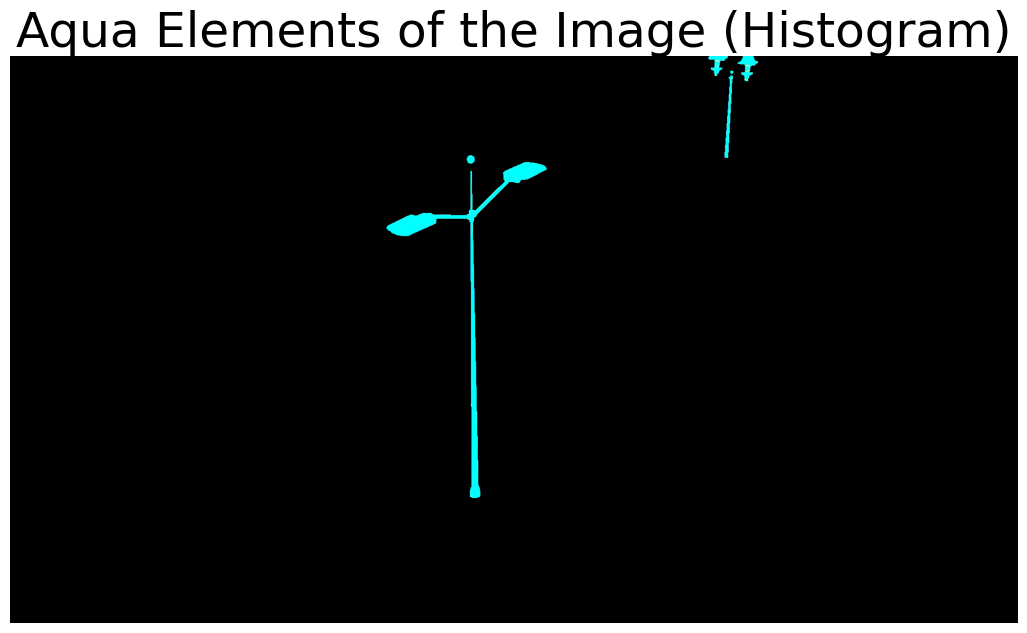

In [1]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath('/C/Users/Renato/Documents/GitHub/pucpr_pibic_semantic_segmentation'))

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from core.validation import get_valid_image_number
from dotenv import load_dotenv

def create_target_histogram():
    # Criar amostra com range de cores aqua
    sample = np.zeros((100, 100, 3), dtype=np.uint8)
    
    # Criar gradiente de cores aqua em BGR
    for i in range(100):
        for j in range(100):
            # Variar B de 70 a 90
            b = int(70 + (j * 20 / 100))
            # Variar G de 82 a 255
            g = int(82 + (i * 173 / 100))
            sample[i,j] = [b, g, 255]
    
    sample_hsv = cv.cvtColor(sample, cv.COLOR_BGR2HSV)
    
    # Calcular histograma
    h_bins = 30
    s_bins = 32
    hist_size = [h_bins, s_bins]
    h_ranges = [0, 180]
    s_ranges = [0, 256]
    ranges = h_ranges + s_ranges
    channels = [0, 1]
    
    hist = cv.calcHist([sample_hsv], channels, None, hist_size, ranges)
    cv.normalize(hist, hist, 0, 255, cv.NORM_MINMAX)
    return hist

def histogram_segmentation(image, target_hist):
    # Converter para HSV
    hsv_img = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    
    # Ajustar range HSV para ser mais específico para aqua
    # Usando valores mais restritos para evitar cores vermelhas
    lower_hsv = np.array([85, 100, 100])  # Aumentar valores mínimos
    upper_hsv = np.array([95, 255, 255])  # Reduzir range
    range_mask = cv.inRange(hsv_img, lower_hsv, upper_hsv)
    
    # Calcular backprojection
    h_bins = 30
    s_bins = 32
    ranges = [0, 180, 0, 256]
    channels = [0, 1]
    
    back_proj = cv.calcBackProject([hsv_img], channels, target_hist, ranges, scale=1)
    back_proj = cv.normalize(back_proj, None, 0, 255, cv.NORM_MINMAX)
    
    # Aumentar peso do range_mask para ser mais seletivo
    combined_mask = cv.addWeighted(range_mask, 0.8, back_proj, 0.2, 0)
    
    # Aumentar threshold para ser mais seletivo
    _, binary_mask = cv.threshold(combined_mask, 40, 255, cv.THRESH_BINARY)
    
    # Operações morfológicas mais suaves
    kernel = np.ones((3,3), np.uint8)
    binary_mask = cv.morphologyEx(binary_mask, cv.MORPH_CLOSE, kernel)
    binary_mask = cv.morphologyEx(binary_mask, cv.MORPH_OPEN, kernel)
    
    return binary_mask

### Setup ###
load_dotenv()
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Carregar imagem
bgr_img = cv.imread(mask_path, 1)

# Aplicar segmentação
target_hist = create_target_histogram()
mask = histogram_segmentation(bgr_img, target_hist)

# Visualização
plt.figure(figsize=[13,13])
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}", fontdict={'fontsize': 25})
plt.axis('off')

plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Aqua Color (Histogram)", fontdict={'fontsize': 25})
plt.axis('off')

# Aplicar máscara
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotar resultado
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Aqua Elements of the Image (Histogram)", fontdict={'fontsize':35})
plt.axis('off')

plt.show()